In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, BayesianRidge
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings

warnings.filterwarnings('ignore')

# Set seaborn style for academic-looking plots
sns.set_theme(style="whitegrid")


In [2]:
# ==========================================
# 1. DATA PREPARATION
# ==========================================
def load_and_prep_data(filepath, sample_size=5000):
    """Loads data, drops existing missing values to create Ground Truth, and samples."""
    df = pd.read_csv(filepath)
    # Drop existing NA to create our "Ground Truth"
    df_clean = df.dropna().reset_index(drop=True)
    
    # Sample down to match the paper's scale (~5000)
    if len(df_clean) > sample_size:
        df_clean = df_clean.sample(n=sample_size, random_state=42).reset_index(drop=True)
        
    X = df_clean.drop('dlq_2yrs', axis=1)
    y = df_clean['dlq_2yrs']
    return X, y

# ==========================================
# 2. MISSING DATA INJECTION (MCAR)
# ==========================================
def inject_mcar_missing_data(X, missing_rate):
    """Injects completely random missing values into the dataframe."""
    X_missing = X.copy()
    np.random.seed(42)
    mask = np.random.rand(*X_missing.shape) < missing_rate
    X_missing[mask] = np.nan
    return X_missing, mask

# ==========================================
# 3. IMPUTATION METHODS
# ==========================================
def apply_imputations(X_missing):
    """Applies the 5 imputation methods aligned with the literature review."""
    imputed_datasets = {}
    
    # 1. Mode Imputation
    mode_imputer = SimpleImputer(strategy='most_frequent')
    imputed_datasets['Mode'] = pd.DataFrame(mode_imputer.fit_transform(X_missing), columns=X_missing.columns)
    
    # 2. KNN Imputation
    knn_imputer = KNNImputer(n_neighbors=5)
    imputed_datasets['KNN'] = pd.DataFrame(knn_imputer.fit_transform(X_missing), columns=X_missing.columns)
    
    # 3. Sequential Hot-Deck (SHD) 
    shd_df = X_missing.copy()
    if 'monthly_inc' in shd_df.columns:
        shd_df = shd_df.sort_values(by='monthly_inc')
    # Use modern pandas syntax (.ffill() and .bfill())
    shd_df = shd_df.ffill().bfill()
    imputed_datasets['SHD'] = shd_df.sort_index() 
    
    # 4. MissForest (Random Forest Imputation)
    missforest_imputer = IterativeImputer(estimator=RandomForestRegressor(n_estimators=10, random_state=42), max_iter=5, random_state=42)
    imputed_datasets['MissForest'] = pd.DataFrame(missforest_imputer.fit_transform(X_missing), columns=X_missing.columns)
    
    # 5. MICE
    mice_imputer = IterativeImputer(estimator=BayesianRidge(), max_iter=10, random_state=42)
    imputed_datasets['MICE'] = pd.DataFrame(mice_imputer.fit_transform(X_missing), columns=X_missing.columns)
    
    return imputed_datasets

# ==========================================
# 4. EVALUATION METRICS
# ==========================================
def evaluate_precision(X_true, imputed_datasets, mask):
    """Calculates Imputation Precision Score (Accuracy of guessed values vs ground truth)."""
    results = {}
    for name, X_imp in imputed_datasets.items():
        true_values = X_true[mask].values.flatten()
        pred_values = X_imp[mask].values.flatten()
        
        valid_idx = ~np.isnan(true_values)
        true_valid = true_values[valid_idx]
        pred_valid = pred_values[valid_idx]
        
        # Rounding simulates the exact-match requirement for categorical/ordinal data
        accuracy = accuracy_score(np.round(true_valid), np.round(pred_valid))
        results[name] = accuracy
    return results

def evaluate_classifiers(X_train_imp_dict, y_train, X_test_clean, y_test):
    """Trains Classifiers and calculates Accuracy, Precision, Recall, and F1-Score."""
    classifiers = {
        'Logistic Regression': LogisticRegression(max_iter=500),
        'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42)
    }
    
    metrics_results = []
    
    for imp_name, X_train_imp in X_train_imp_dict.items():
        for clf_name, clf in classifiers.items():
            # Train on imputed training data
            clf.fit(X_train_imp, y_train)
            
            # Predict on strictly CLEAN test data
            y_pred = clf.predict(X_test_clean)
            
            # Calculate all 4 requested metrics
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, zero_division=0)
            rec = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            
            metrics_results.append({
                'Imputation': imp_name,
                'Classifier': clf_name,
                'Accuracy': acc,
                'Precision': prec,
                'Recall': rec,
                'F1_Score': f1
            })
            
    return metrics_results

Loading and preparing data...

--- Running Experiment for 10% Missing Data ---

--- Running Experiment for 20% Missing Data ---

--- Running Experiment for 30% Missing Data ---

--- Running Experiment for 40% Missing Data ---

--- Running Experiment for 50% Missing Data ---

1. IMPUTATION PRECISION SCORE (Accuracy % of imputed values)
      Mode    KNN    SHD  MissForest   MICE
0.1  89.66  88.84  88.36       89.85  86.67
0.2  84.58  83.27  82.60       84.50  79.92
0.3  79.75  77.19  76.74       78.71  71.82
0.4  74.87  71.33  71.22       73.39  64.41
0.5  69.97  65.17  65.56       67.50  57.15

2. DOWNSTREAM CLASSIFIER PERFORMANCE (Sample Metrics)

--- F1-Scores ---
Imputation                           KNN    MICE  MissForest    Mode     SHD
Missing_Rate Classifier                                                     
0.1          Logistic Regression  0.7109  0.7078      0.7081  0.7175  0.5418
             Random Forest        0.7564  0.7691      0.7565  0.7631  0.4938
0.2          Logi

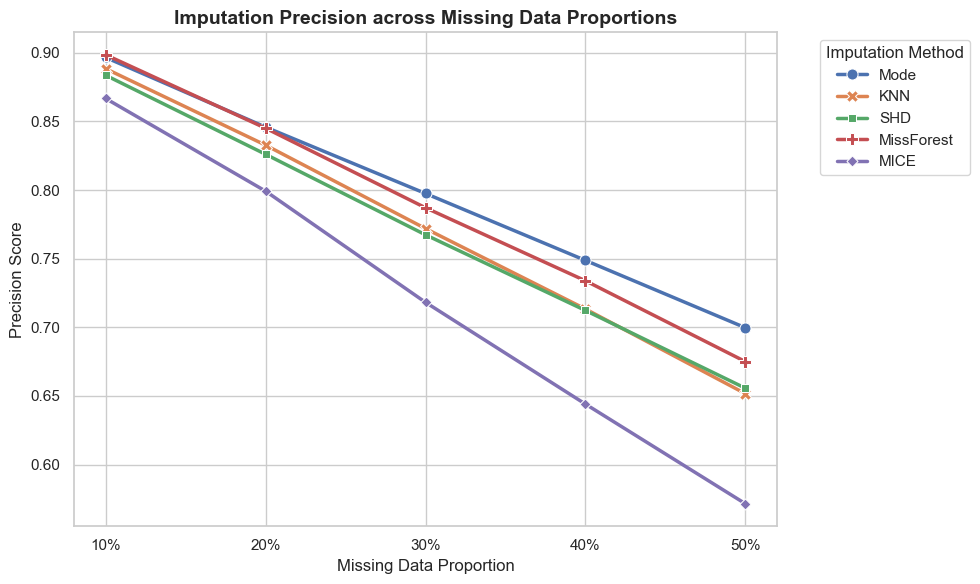

-> Saved Phase1_Precision_Chart.png


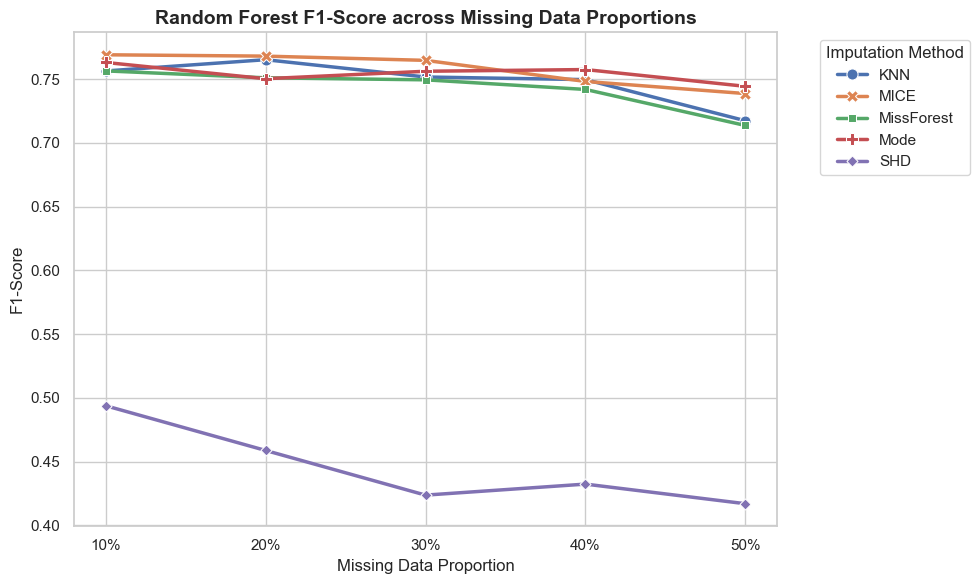

-> Saved Phase2_RF_F1_Chart.png

Experiment complete! Check your directory for CSVs and PNG charts.


In [3]:
# ==========================================
# MAIN EXECUTION LOOP
# ==========================================
if __name__ == "__main__":
    filepath = "./data/Credit Risk Benchmark Dataset.csv"
    print("Loading and preparing data...")
    X_full, y_full = load_and_prep_data(filepath, sample_size=5000)
    
    # 5-State Proportions
    missing_rates = [0.10, 0.20, 0.30, 0.40, 0.50]
    
    precision_report = pd.DataFrame(index=missing_rates)
    classifier_report = []

    for rate in missing_rates:
        print(f"\n--- Running Experiment for {int(rate*100)}% Missing Data ---")
        
        # Phase 1: Imputation Precision Test 
        X_missing, mask = inject_mcar_missing_data(X_full, rate)
        imputed_full_datasets = apply_imputations(X_missing)
        precision_scores = evaluate_precision(X_full, imputed_full_datasets, mask)
        
        for name, score in precision_scores.items():
            precision_report.loc[rate, name] = score
            
        # Phase 2: Downstream Classifier Test 
        X_train_clean, X_test_clean, y_train, y_test = train_test_split(X_full, y_full, test_size=0.30, random_state=42)
        
        # Inject missing data ONLY into training set
        X_train_missing, _ = inject_mcar_missing_data(X_train_clean, rate)
        imputed_train_datasets = apply_imputations(X_train_missing)
        
        # Evaluate classifiers across all metrics
        batch_metrics = evaluate_classifiers(imputed_train_datasets, y_train, X_test_clean, y_test)
        for row in batch_metrics:
            row['Missing_Rate'] = rate
            classifier_report.append(row)

    print("\n==================================================")
    print("1. IMPUTATION PRECISION SCORE (Accuracy % of imputed values)")
    print("==================================================")
    print(precision_report.round(4) * 100)
    
    print("\n==================================================")
    print("2. DOWNSTREAM CLASSIFIER PERFORMANCE (Sample Metrics)")
    print("==================================================")
    df_metrics = pd.DataFrame(classifier_report)
    
    # Display F1-Score as an example pivot table
    f1_pivot = df_metrics.pivot_table(index=['Missing_Rate', 'Classifier'], columns='Imputation', values='F1_Score')
    print("\n--- F1-Scores ---")
    print(f1_pivot.round(4))
    
    # ==========================================
    # 5. DATA EXPORT & VISUALIZATION
    # ==========================================
    print("\nSaving results and generating charts...")
    
    # Save to CSV
    precision_report.to_csv("Phase1_Precision_Results.csv")
    df_metrics.to_csv("Phase2_Classifier_Metrics_Results.csv", index=False)
    f1_pivot.to_csv("Phase2_F1_Pivot_Table.csv")
    
    # Plot 1: Precision Line Plot
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=precision_report, markers=True, dashes=False, linewidth=2.5, markersize=8)
    plt.title('Imputation Precision across Missing Data Proportions', fontsize=14, fontweight='bold')
    plt.xlabel('Missing Data Proportion', fontsize=12)
    plt.ylabel('Precision Score', fontsize=12)
    plt.xticks(missing_rates, [f"{int(r*100)}%" for r in missing_rates])
    plt.legend(title='Imputation Method', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    plt.savefig('Phase1_Precision_Chart.png', dpi=300)
    plt.close()
    print("-> Saved Phase1_Precision_Chart.png")

    # Plot 2: F1-Score for Random Forest
    rf_f1_data = df_metrics[df_metrics['Classifier'] == 'Random Forest'].pivot_table(index='Missing_Rate', columns='Imputation', values='F1_Score')
    
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=rf_f1_data, markers=True, dashes=False, linewidth=2.5, markersize=8)
    plt.title('Random Forest F1-Score across Missing Data Proportions', fontsize=14, fontweight='bold')
    plt.xlabel('Missing Data Proportion', fontsize=12)
    plt.ylabel('F1-Score', fontsize=12)
    plt.xticks(missing_rates, [f"{int(r*100)}%" for r in missing_rates])
    plt.legend(title='Imputation Method', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    plt.savefig('Phase2_RF_F1_Chart.png', dpi=300)
    plt.close()
    print("-> Saved Phase2_RF_F1_Chart.png")
    
    print("\nExperiment complete! Check your directory for CSVs and PNG charts.")